In [1]:
import polars as pl

lf = pl.scan_parquet("../data/processed/fannie_2017_features_added.parquet")

schema = lf.collect_schema()
for name, dtype in schema.items():
    print(f"{name:35} {dtype}")

print("\nrows:", lf.select(pl.len()).collect().item())

LOAN_ID                             String
POOL_ID                             String
ACT_PERIOD                          String
CHANNEL                             String
SELLER                              String
SERVICER                            String
MASTER_SERVICER                     String
ORIG_RATE                           Float64
CURR_RATE                           String
ORIG_UPB                            Float64
ISSUANCE_UPB                        String
CURRENT_UPB                         String
ORIG_TERM                           Float64
ORIG_DATE                           String
FIRST_PAY                           String
LOAN_AGE                            String
REM_MONTHS                          String
ADJ_REM_MONTHS                      String
MATR_DT                             String
OLTV                                String
OCLTV                               String
NUM_BO                              String
DTI                                 String
CSCORE_B

## Inspect string columns before casting

**What**
- Print sample values, null counts, and unparseable values for the 7 text columns that should be numeric.
- Read-only. Writes nothing, changes nothing.

**Why**
- `OLTV`, `OCLTV`, `DTI`, and 4 others are stored as text, not numbers. Cannot be averaged, plotted, sorted, or modeled until fixed.
- `.cast(pl.Float64)` fails silently on junk values like `""` or `"N/A"`. It does not error, it returns null. A blind cast can quietly delete data and we would not find out until model results look wrong.
- This step finds the junk first so the cast in Step 2 is deliberate.

**What to look for**
- Block 3 is the decision point. Empty lists for every column means the cast is safe and Step 2 is a one-liner.
- Non-empty means we need an explicit cleaning rule per column before casting.

In [2]:
TO_CAST = ["OLTV", "OCLTV", "DTI", "CSCORE_C", "NUM_BO", "NO_UNITS", "MI_PCT"]

print("--- sample values ---")
print(lf.select(TO_CAST).head(8).collect())

print("\n--- null counts (as String) ---")
print(
    lf.select([pl.col(c).null_count().alias(c) for c in TO_CAST]).collect()
)

print("\n--- values that will NOT cast to Float64 ---")
for c in TO_CAST:
    bad = (
        lf.select(c)
        .filter(
            pl.col(c).is_not_null()
            & pl.col(c).cast(pl.Float64, strict=False).is_null()
        )
        .unique()
        .head(5)
        .collect()
        .to_series()
        .to_list()
    )
    print(f"{c:10} {len(bad)} distinct bad values shown: {bad}")

--- sample values ---
shape: (8, 7)
┌──────┬───────┬─────┬──────────┬────────┬──────────┬────────┐
│ OLTV ┆ OCLTV ┆ DTI ┆ CSCORE_C ┆ NUM_BO ┆ NO_UNITS ┆ MI_PCT │
│ ---  ┆ ---   ┆ --- ┆ ---      ┆ ---    ┆ ---      ┆ ---    │
│ str  ┆ str   ┆ str ┆ str      ┆ str    ┆ str      ┆ str    │
╞══════╪═══════╪═════╪══════════╪════════╪══════════╪════════╡
│ 97   ┆ 97    ┆ 39  ┆ null     ┆ 1      ┆ 1        ┆ 25.00  │
│ 41   ┆ 41    ┆ 19  ┆ null     ┆ 1      ┆ 1        ┆ null   │
│ 78   ┆ 78    ┆ 41  ┆ 800      ┆ 2      ┆ 1        ┆ null   │
│ 67   ┆ 67    ┆ 29  ┆ 774      ┆ 2      ┆ 1        ┆ null   │
│ 75   ┆ 75    ┆ 44  ┆ 689      ┆ 2      ┆ 1        ┆ null   │
│ 80   ┆ 80    ┆ 31  ┆ null     ┆ 1      ┆ 1        ┆ null   │
│ 95   ┆ 95    ┆ 25  ┆ 779      ┆ 2      ┆ 1        ┆ 30.00  │
│ 54   ┆ 54    ┆ 30  ┆ 723      ┆ 2      ┆ 1        ┆ null   │
└──────┴───────┴─────┴──────────┴────────┴──────────┴────────┘

--- null counts (as String) ---
shape: (1, 7)
┌──────┬───────┬─────┬──────────┬──

## Cast types and write the typed file

**What**
- Cast the 7 verified-clean text columns to numeric.
- Write a new file: `fannie_2017_typed.parquet`. The source file is untouched.

**Why**
- Types only. No fills, no drops, no new columns.
- Semantic fills (`MI_PCT` null to 0, etc.) belong in feature prep as code, not baked into a file. The EDA track may want to see nulls as nulls to identify which loans carry no MI.
- Keeping this to one job means if something breaks later we know it was not the cast.

**Verification built in**
- Null counts must be unchanged. If nulls went up, the cast silently ate data.
- Min/max on each column. Fannie uses sentinel codes (e.g. 999) in some fields; a max of 999 on DTI means we have a fake value pretending to be real.

In [3]:
OUT = "../data/processed/fannie_2017_typed.parquet"

FLOAT_COLS = ["OLTV", "OCLTV", "DTI", "MI_PCT"]
INT_COLS = ["CSCORE_C", "NUM_BO", "NO_UNITS"]

(
    lf.with_columns(
        [pl.col(c).cast(pl.Float64) for c in FLOAT_COLS]
        + [pl.col(c).cast(pl.Int32) for c in INT_COLS]
    ).sink_parquet(OUT)
)

lft = pl.scan_parquet(OUT)

print("--- rows ---")
print(lft.select(pl.len()).collect().item())

print("\n--- null counts after cast (must be unchanged) ---")
print(lft.select([pl.col(c).null_count().alias(c) for c in TO_CAST]).collect())

print("\n--- ranges (watch for sentinel values) ---")
print(
    lft.select(
        [pl.col(c).min().alias(f"{c}_min") for c in TO_CAST]
        + [pl.col(c).max().alias(f"{c}_max") for c in TO_CAST]
    ).collect().transpose(include_header=True)
)

--- rows ---
2046851

--- null counts after cast (must be unchanged) ---
shape: (1, 7)
┌──────┬───────┬─────┬──────────┬────────┬──────────┬─────────┐
│ OLTV ┆ OCLTV ┆ DTI ┆ CSCORE_C ┆ NUM_BO ┆ NO_UNITS ┆ MI_PCT  │
│ ---  ┆ ---   ┆ --- ┆ ---      ┆ ---    ┆ ---      ┆ ---     │
│ u32  ┆ u32   ┆ u32 ┆ u32      ┆ u32    ┆ u32      ┆ u32     │
╞══════╪═══════╪═════╪══════════╪════════╪══════════╪═════════╡
│ 0    ┆ 0     ┆ 340 ┆ 1083143  ┆ 0      ┆ 0        ┆ 1432111 │
└──────┴───────┴─────┴──────────┴────────┴──────────┴─────────┘

--- ranges (watch for sentinel values) ---
shape: (14, 2)
┌──────────────┬──────────┐
│ column       ┆ column_0 │
│ ---          ┆ ---      │
│ str          ┆ f64      │
╞══════════════╪══════════╡
│ OLTV_min     ┆ 2.0      │
│ OCLTV_min    ┆ 2.0      │
│ DTI_min      ┆ 1.0      │
│ CSCORE_C_min ┆ 620.0    │
│ NUM_BO_min   ┆ 1.0      │
│ …            ┆ …        │
│ DTI_max      ┆ 63.0     │
│ CSCORE_C_max ┆ 839.0    │
│ NUM_BO_max   ┆ 6.0      │
│ NO_UNITS_max

## Re-display ranges without truncation

**What**
- Same min/max check, forced to print all 14 rows.
- Plus a count of `OLTV` above 100.

**Why**
- Default Polars display collapsed the middle rows. `OLTV_max` was in the collapsed block.
- `OLTV` is where a sentinel would hide. Standard Fannie caps around 97, some programs reach 105. A max of 999 means a fake value in our strongest LTV feature.
- The `OLTV > 100` count separates "a few legitimate high-LTV program loans" from "a block of sentinels."

In [4]:
with pl.Config(tbl_rows=-1):
    print(
        lft.select(
            [pl.col(c).min().alias(f"{c}_min") for c in TO_CAST]
            + [pl.col(c).max().alias(f"{c}_max") for c in TO_CAST]
        ).collect().transpose(include_header=True)
    )

print("\n--- OLTV above 100 ---")
print(
    lft.filter(pl.col("OLTV") > 100)
       .select(pl.len().alias("n"), pl.col("OLTV").max().alias("max"))
       .collect()
)

shape: (14, 2)
┌──────────────┬──────────┐
│ column       ┆ column_0 │
│ ---          ┆ ---      │
│ str          ┆ f64      │
╞══════════════╪══════════╡
│ OLTV_min     ┆ 2.0      │
│ OCLTV_min    ┆ 2.0      │
│ DTI_min      ┆ 1.0      │
│ CSCORE_C_min ┆ 620.0    │
│ NUM_BO_min   ┆ 1.0      │
│ NO_UNITS_min ┆ 1.0      │
│ MI_PCT_min   ┆ 6.0      │
│ OLTV_max     ┆ 97.0     │
│ OCLTV_max    ┆ 114.0    │
│ DTI_max      ┆ 63.0     │
│ CSCORE_C_max ┆ 839.0    │
│ NUM_BO_max   ┆ 6.0      │
│ NO_UNITS_max ┆ 4.0      │
│ MI_PCT_max   ┆ 40.0     │
└──────────────┴──────────┘

--- OLTV above 100 ---
shape: (1, 2)
┌─────┬──────┐
│ n   ┆ max  │
│ --- ┆ ---  │
│ u32 ┆ f64  │
╞═════╪══════╡
│ 0   ┆ null │
└─────┴──────┘


## Assign the split in memory

**What**
- Collect the ~34 admissible + LP columns from the typed file into `df`.
- Add a `split` column via `hash(LOAN_ID) % 100`: 0-59 train, 60-79 calib, 80-99 test.
- No new parquet. `df` lives in the session.

**Why no file**
- The split is deterministic from `LOAN_ID`. Any teammate reruns this cell and gets identical splits. Nothing to persist.
- Writing 2M rows on every iteration was the bottleneck, and it bought nothing.

**Why hash instead of shuffle**
- Same loan lands in the same split every run, on every machine, with no stored seed.
- Pure column math. No shuffle, no window, no join.

**Not exactly stratified, and that's fine**
- Random assignment drifts the test default rate by roughly ±0.03%.
- Invisible to AUC and calibration. Verified empirically below instead of guaranteed structurally.

**Timers**
- Each step is timed. If something is slow we will know which line instead of guessing.

In [5]:
import time

SEED = 591

KEEP = [
    "LOAN_ID", "default_flag",
    "CSCORE_B", "CSCORE_C", "OLTV", "OCLTV", "DTI",
    "ORIG_RATE", "ORIG_UPB", "ORIG_TERM", "NUM_BO", "NO_UNITS", "MI_PCT",
    "CHANNEL", "SELLER", "PURPOSE", "PROP", "OCC_STAT", "STATE",
    "PRODUCT", "MI_TYPE", "FIRST_FLAG", "PPMT_FLG", "IO",
    "HIGH_BALANCE_LOAN_INDICATOR", "PROPERTY_INSPECTION_WAIVER_INDICATOR",
    "RELOCATION_MORTGAGE_INDICATOR",
    "is_first_time", "is_homeready", "is_hfa",
    "interest_income_7yr", "loss_if_default", "lgd",
    "credit_grade", "orig_quarter",
]

t0 = time.time()
df = lft.select(KEEP).collect()
t1 = time.time()
print(f"collect      : {t1-t0:6.1f}s   shape={df.shape}")

df = (
    df.with_columns((pl.col("LOAN_ID").hash(seed=SEED) % 100).alias("_b"))
      .with_columns(
          pl.when(pl.col("_b") < 60).then(pl.lit("train"))
            .when(pl.col("_b") < 80).then(pl.lit("calib"))
            .otherwise(pl.lit("test"))
            .alias("split")
      )
      .drop("_b")
)
t2 = time.time()
print(f"split assign : {t2-t1:6.1f}s")

print("\n--- split sizes and default rate ---")
print(
    df.group_by("split")
      .agg(
          pl.len().alias("n"),
          pl.col("default_flag").sum().alias("positives"),
          pl.col("default_flag").mean().alias("default_rate"),
      )
      .sort("split")
)
print(f"\nsplit nulls: {df['split'].null_count()}   memory: {df.estimated_size('mb'):.0f} MB")

collect      :    0.0s   shape=(2046851, 35)
split assign :    0.0s

--- split sizes and default rate ---
shape: (3, 4)
┌───────┬─────────┬───────────┬──────────────┐
│ split ┆ n       ┆ positives ┆ default_rate │
│ ---   ┆ ---     ┆ ---       ┆ ---          │
│ str   ┆ u32     ┆ i64       ┆ f64          │
╞═══════╪═════════╪═══════════╪══════════════╡
│ calib ┆ 409353  ┆ 14094     ┆ 0.03443      │
│ test  ┆ 409926  ┆ 13982     ┆ 0.034109     │
│ train ┆ 1227572 ┆ 41810     ┆ 0.034059     │
└───────┴─────────┴───────────┴──────────────┘

split nulls: 0   memory: 319 MB


## Synthetic PD generator

**What**
- Produce a fake but plausible `pd` per loan for the test split.
- Emit the exact schema the real model will emit, so swapping in week 6 is a one-line change.

**Why now**
- The LP and Monte Carlo need a PD column, not a good PD column. Waiting for the real model blocks stages 3 and 4 for weeks.
- This is the data contract from the launch report, made concrete. Lock the schema now and the LP never has to change.

**Why build it from real FICO / OLTV / DTI instead of random draws**
- The LP's average-PD ceiling and state caps interact with *which* loans are risky. Random PDs would scatter risk uniformly across states and FICO bands, so the constraints would behave nothing like they will on real PDs.
- Built from real features, risky loans cluster where they actually cluster. The LP prototype behaves like the real thing.
- Free side effect: it has genuine signal against `default_flag`, so we can sanity-check with AUC.

**Method**
- Logistic function on standardized FICO, OLTV, DTI, plus noise.
- Coefficients are hand-set to mortgage-plausible signs and magnitudes. FICO dominant and negative, LTV and DTI positive.
- Intercept solved numerically so mean PD lands on the observed 3.4143%.

**Throwaway.** No tuning, no validation. It exists to be deleted.

In [6]:
import numpy as np

def make_synthetic_pd(frame, target_rate=0.034143, seed=591):
    rng = np.random.default_rng(seed)

    d = frame.with_columns([
        pl.col("CSCORE_B").fill_null(pl.col("CSCORE_B").median()),
        pl.col("OLTV").fill_null(pl.col("OLTV").median()),
        pl.col("DTI").fill_null(pl.col("DTI").median()),
    ])

    z = lambda c: ((pl.col(c) - pl.col(c).mean()) / pl.col(c).std())
    d = d.with_columns([
        z("CSCORE_B").alias("_zf"),
        z("OLTV").alias("_zl"),
        z("DTI").alias("_zd"),
    ])

    lp = (
        -0.90 * d["_zf"].to_numpy()
        + 0.40 * d["_zl"].to_numpy()
        + 0.25 * d["_zd"].to_numpy()
        + rng.normal(0, 0.50, len(d))
    )

    lo, hi = -12.0, 2.0
    for _ in range(60):
        mid = (lo + hi) / 2
        if (1 / (1 + np.exp(-(lp + mid)))).mean() < target_rate:
            lo = mid
        else:
            hi = mid
    pd_vals = 1 / (1 + np.exp(-(lp + (lo + hi) / 2)))

    return frame.select(
        "LOAN_ID", "ORIG_UPB", "interest_income_7yr",
        "loss_if_default", "STATE", "credit_grade", "default_flag",
    ).with_columns(pl.Series("pd", pd_vals))


pool = make_synthetic_pd(df.filter(pl.col("split") == "test"))

print("--- contract schema (what the LP consumes) ---")
for n, t in pool.schema.items():
    print(f"  {n:22} {t}")

print(f"\nrows        : {len(pool):,}")
print(f"mean pd     : {pool['pd'].mean():.6f}   (target 0.034143)")
print(f"actual rate : {pool['default_flag'].mean():.6f}")

print("\n--- pd distribution ---")
print(pool["pd"].describe())

from sklearn.metrics import roc_auc_score
print(f"\nsynthetic AUC vs real default_flag: "
      f"{roc_auc_score(pool['default_flag'], pool['pd']):.4f}")

--- contract schema (what the LP consumes) ---
  LOAN_ID                String
  ORIG_UPB               Float64
  interest_income_7yr    Float64
  loss_if_default        Float64
  STATE                  String
  credit_grade           String
  default_flag           Int8
  pd                     Float64

rows        : 409,926
mean pd     : 0.034143   (target 0.034143)
actual rate : 0.034109

--- pd distribution ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 409926.0 │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.034143 │
│ std        ┆ 0.045098 │
│ min        ┆ 0.000188 │
│ 25%        ┆ 0.007781 │
│ 50%        ┆ 0.017309 │
│ 75%        ┆ 0.041353 │
│ max        ┆ 0.565142 │
└────────────┴──────────┘

synthetic AUC vs real default_flag: 0.7178


## Inspect categoricals before encoding

**What**
- Cardinality, nulls, and value counts for the 14 categorical columns.
- Read-only.

**Why**
- Same discipline as inspecting strings before casting. Encode blind and you get silent damage.
- `SELLER` is the known problem. Fannie has hundreds of sellers with a long tail of tiny ones. One-hot on raw `SELLER` would add hundreds of columns, most firing on a handful of loans each, and LogReg would happily overfit them.
- Constant columns waste space and confuse coefficient interpretation. `PRODUCT` is likely constant on a 2017 fixed-rate book.
- LogReg needs one-hot. XGBoost and LightGBM take categoricals natively. The encoding plan depends on what is actually in here.

**What to look for**
- Any column with `n_unique = 1` gets dropped.
- `SELLER` cardinality decides whether we group the tail or drop it.
- Nulls in categoricals need a rule, same as the numerics.

In [7]:
CAT = [
    "CHANNEL", "SELLER", "PURPOSE", "PROP", "OCC_STAT", "STATE",
    "PRODUCT", "MI_TYPE", "FIRST_FLAG", "PPMT_FLG", "IO",
    "HIGH_BALANCE_LOAN_INDICATOR", "PROPERTY_INSPECTION_WAIVER_INDICATOR",
    "RELOCATION_MORTGAGE_INDICATOR",
]

print("--- cardinality and nulls ---")
print(
    df.select(
        [pl.col(c).n_unique().alias(c) for c in CAT]
    ).transpose(include_header=True, column_names=["n_unique"])
    .join(
        df.select([pl.col(c).null_count().alias(c) for c in CAT])
          .transpose(include_header=True, column_names=["nulls"]),
        on="column",
    )
    .sort("n_unique", descending=True)
)

print("\n--- value counts for low-cardinality columns ---")
for c in CAT:
    k = df[c].n_unique()
    if k <= 8:
        print(f"\n{c}  (k={k})")
        print(df[c].value_counts(sort=True))

print("\n--- SELLER top 10 ---")
print(df["SELLER"].value_counts(sort=True).head(10))

--- cardinality and nulls ---
shape: (14, 3)
┌─────────────────────────────────┬──────────┬───────┐
│ column                          ┆ n_unique ┆ nulls │
│ ---                             ┆ ---      ┆ ---   │
│ str                             ┆ u32      ┆ u32   │
╞═════════════════════════════════╪══════════╪═══════╡
│ STATE                           ┆ 54       ┆ 0     │
│ SELLER                          ┆ 38       ┆ 0     │
│ PROP                            ┆ 5        ┆ 0     │
│ PROPERTY_INSPECTION_WAIVER_IND… ┆ 4        ┆ 0     │
│ CHANNEL                         ┆ 3        ┆ 0     │
│ …                               ┆ …        ┆ …     │
│ IO                              ┆ 2        ┆ 1     │
│ HIGH_BALANCE_LOAN_INDICATOR     ┆ 2        ┆ 0     │
│ RELOCATION_MORTGAGE_INDICATOR   ┆ 2        ┆ 0     │
│ PRODUCT                         ┆ 1        ┆ 0     │
│ PPMT_FLG                        ┆ 1        ┆ 0     │
└─────────────────────────────────┴──────────┴───────┘

--- value counts fo

## Verify the duplicate pair and inspect SELLER

**What**
- Cross-tab `FIRST_FLAG` against `is_first_time` to confirm they are the same column.
- Default rate by `SELLER`, to see whether it carries signal and whether the Quicken entities behave alike.

**Why**
- Do not drop a column on the assumption it duplicates another. Verify, then drop.
- If the two Quicken entities have materially different default rates they may be different books despite the shared name, and merging would blur signal. If they match, merging is safe.
- If `SELLER` default rates are flat across the board, it earns no place in the model and 37 dummies go away.

In [8]:
print("--- FIRST_FLAG vs is_first_time ---")
print(df.group_by("FIRST_FLAG", "is_first_time").len().sort("FIRST_FLAG"))

print("\n--- default rate by SELLER (n >= 20k) ---")
print(
    df.group_by("SELLER")
      .agg(
          pl.len().alias("n"),
          pl.col("default_flag").mean().alias("rate"),
      )
      .filter(pl.col("n") >= 20_000)
      .sort("rate", descending=True)
      .with_columns(pl.col("rate").round(4))
)

--- FIRST_FLAG vs is_first_time ---
shape: (2, 3)
┌────────────┬───────────────┬─────────┐
│ FIRST_FLAG ┆ is_first_time ┆ len     │
│ ---        ┆ ---           ┆ ---     │
│ str        ┆ i8            ┆ u32     │
╞════════════╪═══════════════╪═════════╡
│ N          ┆ 0             ┆ 1558365 │
│ Y          ┆ 1             ┆ 488486  │
└────────────┴───────────────┴─────────┘

--- default rate by SELLER (n >= 20k) ---
shape: (18, 3)
┌─────────────────────────────────┬────────┬────────┐
│ SELLER                          ┆ n      ┆ rate   │
│ ---                             ┆ ---    ┆ ---    │
│ str                             ┆ u32    ┆ f64    │
╞═════════════════════════════════╪════════╪════════╡
│ U.S. Bank N.A.                  ┆ 45849  ┆ 0.0848 │
│ Loandepot.Com, Llc              ┆ 28345  ┆ 0.0461 │
│ Caliber Home Loans, Inc.        ┆ 24056  ┆ 0.0425 │
│ Flagstar Bank, Fsb              ┆ 40402  ┆ 0.0417 │
│ Wells Fargo Bank, N.A.          ┆ 309551 ┆ 0.0414 │
│ …                     

## Session display config

**What**
- Set Polars display once, globally, for the session.
- Run near the top of the notebook.

**Why**
- Polars collapses tables past ~10 rows and truncates strings past ~30 chars by default.
- We keep hitting it on 14-row, 38-row, 54-row tables and re-running to see the middle. `STATE` at 54 rows and `SELLER` at 38 would both truncate every time.
- Set once, never think about it again.

In [9]:
pl.Config.set_tbl_rows(200)
pl.Config.set_tbl_cols(50)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

## SELLER: signal or proxy

**What**
- Full seller table, no truncation.
- Default rate alongside mean FICO, OLTV, DTI per seller.

**Why**
- A raw default rate by seller cannot distinguish worse underwriting from a riskier loan mix. Putting the credit characteristics next to the rate makes it visible by eye.
- Decides whether `SELLER` earns 37 dummies in LogReg or gets dropped as redundant with FICO and LTV.
- Also surfaces the two Quicken entities, which the default display collapsed.

In [10]:
with pl.Config(tbl_rows=-1, fmt_str_lengths=40):
    print(
        df.group_by("SELLER")
          .agg(
              pl.len().alias("n"),
              pl.col("default_flag").mean().round(4).alias("rate"),
              pl.col("CSCORE_B").mean().round(0).alias("fico"),
              pl.col("OLTV").mean().round(1).alias("oltv"),
              pl.col("DTI").mean().round(1).alias("dti"),
          )
          .filter(pl.col("n") >= 20_000)
          .sort("rate", descending=True)
    )

shape: (18, 6)
┌───────────────────────────────────────────┬────────┬────────┬───────┬──────┬──────┐
│ SELLER                                    ┆ n      ┆ rate   ┆ fico  ┆ oltv ┆ dti  │
│ ---                                       ┆ ---    ┆ ---    ┆ ---   ┆ ---  ┆ ---  │
│ str                                       ┆ u32    ┆ f64    ┆ f64   ┆ f64  ┆ f64  │
╞═══════════════════════════════════════════╪════════╪════════╪═══════╪══════╪══════╡
│ U.S. Bank N.A.                            ┆ 45849  ┆ 0.0848 ┆ 739.0 ┆ 84.8 ┆ 35.6 │
│ Loandepot.Com, Llc                        ┆ 28345  ┆ 0.0461 ┆ 732.0 ┆ 70.7 ┆ 36.1 │
│ Caliber Home Loans, Inc.                  ┆ 24056  ┆ 0.0425 ┆ 741.0 ┆ 77.0 ┆ 35.4 │
│ Flagstar Bank, Fsb                        ┆ 40402  ┆ 0.0417 ┆ 747.0 ┆ 71.4 ┆ 35.0 │
│ Wells Fargo Bank, N.A.                    ┆ 309551 ┆ 0.0414 ┆ 753.0 ┆ 76.2 ┆ 34.9 │
│ Nationstar Mortgage, Llc                  ┆ 26094  ┆ 0.0383 ┆ 737.0 ┆ 71.4 ┆ 35.3 │
│ Movement Mortgage, Llc               

## Finding: SELLER carries signal beyond loan characteristics

Default rates span 2.21% to 8.48% across 37 sellers. Book average is 3.41%.

Loan mix does not explain it:

| Seller | FICO | OLTV | DTI | Rate |
|---|---|---|---|---|
| U.S. Bank | 739 | 84.8 | 35.6 | 8.48% |
| Pmtt4 | 754 | 83.1 | 35.7 | 3.54% |
| Movement Mortgage | 750 | 81.5 | 35.4 | 3.83% |

Same LTV, same DTI, 15 FICO points apart, less than half the default rate. A
15-point FICO gap in the 740s moves risk 20-30%, not 140%.

**Effect:** `SELLER` stays as a feature. Cardinality is 38, not hundreds, because
Fannie pre-buckets small originators into `Other`. No tail grouping needed.
`Quicken Loans, Llc` and `Quicken Loans Inc.` are the same book (3.04% vs 3.06%,
FICO 740 vs 741) and were merged. 38 → 37.

**Two caveats.** `Other` is 932,204 loans, 45.5% of the book. It is Fannie's
catch-all, so the largest level means "unknown lender." And U.S. Bank is a named
public company: we can say its 2017 loans defaulted at 2.4x the book rate and
FICO/LTV/DTI do not explain it. We cannot say anything about its underwriting.
One vintage, and channel and geography are uncontrolled.

## Feature prep

**What**
- Drop constants and the confirmed duplicate.
- Merge the two Quicken entities.
- Apply the null rules.
- Emit `X_num`, `X_cat`, and the final feature lists.

**Drops**
- `PRODUCT`, `PPMT_FLG`, `IO`: zero variance. All-FRM book also confirms the ARM block is dead.
- `FIRST_FLAG`: verified duplicate of `is_first_time`. Keeping the Int8.
- `credit_grade`: reserved for the naive baseline scorer. Collinear with `CSCORE_B`.
- `orig_quarter`: origination-time and admissible, but we chose a random split deliberately. Feeding origination timing to the model invites it to learn the seasoning artifact we agreed to treat as a limitation. Held out.

**Null rules (closing the OPEN items in ml_data.md)**
- `MI_PCT` null to 0. Zero coverage is the true value. Verified: `MI_TYPE` nulls match `MI_PCT` nulls exactly at 1,432,111, so both are structural.
- `MI_TYPE` null to `"NONE"`. Same loans, same reason.
- `CSCORE_C` null to 0 plus `has_coborrower` indicator. There is no co-borrower score to estimate when there is no co-borrower. The indicator carries the meaning; the 0 is inert padding for the model.
- `CSCORE_B` null (1,573) to median plus `fico_missing` indicator. Missing FICO may itself be signal.
- `DTI` null (340) to median. 0.017% of rows. Too small for an indicator to be estimable.

**Not doing yet**
- No new features. `rep_fico = min(CSCORE_B, CSCORE_C)` and `second_lien = OCLTV - OLTV` stay parked until baselines exist.

**Verification built in**
- Variance check on every numeric. `ORIG_TERM` has not been checked and may be near-constant at 360.
- Null count after prep must be zero everywhere.

In [11]:
DROP_CONST = ["PRODUCT", "PPMT_FLG", "IO"]

feat = (
    df.with_columns(
        pl.col("SELLER").str.replace("Quicken Loans Inc.", "Quicken Loans, Llc", literal=True)
    )
    .with_columns([
        pl.col("CSCORE_C").is_not_null().cast(pl.Int8).alias("has_coborrower"),
        pl.col("CSCORE_B").is_null().cast(pl.Int8).alias("fico_missing"),
    ])
    .with_columns([
        pl.col("MI_PCT").fill_null(0.0),
        pl.col("MI_TYPE").fill_null("NONE"),
        pl.col("CSCORE_C").fill_null(0),
        pl.col("CSCORE_B").fill_null(pl.col("CSCORE_B").median()),
        pl.col("DTI").fill_null(pl.col("DTI").median()),
    ])
    .drop(DROP_CONST + ["FIRST_FLAG"])
)

NUM = ["CSCORE_B", "CSCORE_C", "OLTV", "OCLTV", "DTI", "ORIG_RATE",
       "ORIG_UPB", "ORIG_TERM", "NUM_BO", "NO_UNITS", "MI_PCT"]
FLG = ["is_first_time", "is_homeready", "is_hfa", "has_coborrower", "fico_missing"]
CATF = ["CHANNEL", "SELLER", "PURPOSE", "PROP", "OCC_STAT", "STATE",
        "MI_TYPE", "HIGH_BALANCE_LOAN_INDICATOR",
        "PROPERTY_INSPECTION_WAIVER_INDICATOR", "RELOCATION_MORTGAGE_INDICATOR"]

print("--- numeric variance (drop anything with n_unique = 1) ---")
print(
    feat.select([pl.col(c).n_unique().alias(c) for c in NUM + FLG])
        .transpose(include_header=True, column_names=["n_unique"])
        .sort("n_unique")
)

print("\n--- nulls after prep (all must be 0) ---")
nulls = feat.select([pl.col(c).null_count().alias(c) for c in NUM + FLG + CATF])
print(nulls.transpose(include_header=True, column_names=["nulls"])
           .filter(pl.col("nulls") > 0))
print("(empty above = clean)")

print(f"\nSELLER levels after merge: {feat['SELLER'].n_unique()}  (was 38)")
print(f"features: {len(NUM)} numeric + {len(FLG)} flags + {len(CATF)} categorical")
print(f"shape: {feat.shape}")

--- numeric variance (drop anything with n_unique = 1) ---
shape: (16, 2)
┌────────────────┬──────────┐
│ column         ┆ n_unique │
│ ---            ┆ ---      │
│ str            ┆ u32      │
╞════════════════╪══════════╡
│ is_first_time  ┆ 2        │
│ is_homeready   ┆ 2        │
│ is_hfa         ┆ 2        │
│ has_coborrower ┆ 2        │
│ fico_missing   ┆ 2        │
│ NO_UNITS       ┆ 4        │
│ NUM_BO         ┆ 6        │
│ MI_PCT         ┆ 29       │
│ DTI            ┆ 58       │
│ OLTV           ┆ 96       │
│ OCLTV          ┆ 112      │
│ CSCORE_C       ┆ 218      │
│ CSCORE_B       ┆ 221      │
│ ORIG_TERM      ┆ 235      │
│ ORIG_UPB       ┆ 969      │
│ ORIG_RATE      ┆ 2141     │
└────────────────┴──────────┘

--- nulls after prep (all must be 0) ---
shape: (0, 2)
┌────────┬───────┐
│ column ┆ nulls │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
└────────┴───────┘
(empty above = clean)

SELLER levels after merge: 37  (was 38)
features: 11 numeric + 5 flags + 

## Check ORIG_TERM against the 7-year income window

**What**
- Distribution of `ORIG_TERM`, plus range.
- For loans with `ORIG_TERM < 84`, compare `interest_income_7yr` to total lifetime interest.

**Why**
- `interest_income_7yr` assumes an 84-month window. Loans shorter than that are paid off first.
- If the column was computed by running amortization to 84 months regardless of term, short loans are credited with interest on a zero balance. That inflates their objective coefficient and the LP would preferentially fund them.
- For a loan with term < 84, correct behavior is `interest_income_7yr` = full lifetime interest.

**The test**
- Lifetime interest = `monthly_payment` x `ORIG_TERM` - `ORIG_UPB`.
- If `interest_income_7yr` exceeds that for short-term loans, the column is wrong.

In [28]:
print("--- ORIG_TERM ---")
print(feat["ORIG_TERM"].describe())
print(feat["ORIG_TERM"].value_counts(sort=True).head(8))

short = (
    lft.filter(pl.col("ORIG_TERM") < 84)
       .select(
           "ORIG_TERM", "ORIG_UPB", "ORIG_RATE",
           "interest_income_7yr",
           (pl.col("monthly_payment") * pl.col("ORIG_TERM") - pl.col("ORIG_UPB"))
               .round(0).alias("lifetime_interest"),
       )
       .collect()
)

print(f"\nloans with term < 84 months: {len(short):,}")
if len(short):
    print(short.head(5))

--- ORIG_TERM ---
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 2.046851e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 321.932509 │
│ std        ┆ 72.386825  │
│ min        ┆ 36.0       │
│ 25%        ┆ 360.0      │
│ 50%        ┆ 360.0      │
│ 75%        ┆ 360.0      │
│ max        ┆ 360.0      │
└────────────┴────────────┘
shape: (8, 2)
┌───────────┬─────────┐
│ ORIG_TERM ┆ count   │
│ ---       ┆ ---     │
│ f64       ┆ u32     │
╞═══════════╪═════════╡
│ 360.0     ┆ 1577778 │
│ 180.0     ┆ 302536  │
│ 240.0     ┆ 107811  │
│ 120.0     ┆ 34215   │
│ 300.0     ┆ 10886   │
│ 96.0      ┆ 1644    │
│ 144.0     ┆ 1343    │
│ 348.0     ┆ 980     │
└───────────┴─────────┘

loans with term < 84 months: 9
shape: (5, 5)
┌───────────┬──────────┬───────────┬─────────────────────┬───────────────────┐
│ ORIG_TERM ┆ ORIG_UPB ┆ ORIG_RATE ┆ interest_income_7yr ┆ lifetime_inter

## Default rate by loan term

**What**
- Default rate and mean FICO by `ORIG_TERM`, for the five terms with real mass.

**Why**
- Confirms whether `ORIG_TERM` carries signal or proxies for FICO, same test we ran on `SELLER`.
- Quantifies the LP tilt: if 15-year loans default materially less, the objective's preference for 30-year paper is systematically steering toward risk, and that belongs in the report.

In [14]:
print(
    feat.filter(pl.col("ORIG_TERM").is_in([120, 180, 240, 300, 360]))
        .group_by("ORIG_TERM")
        .agg(
            pl.len().alias("n"),
            pl.col("default_flag").mean().round(4).alias("rate"),
            pl.col("CSCORE_B").mean().round(0).alias("fico"),
            pl.col("OLTV").mean().round(1).alias("oltv"),
            pl.col("ORIG_RATE").mean().round(2).alias("rate_pct"),
        )
        .sort("ORIG_TERM")
)

shape: (5, 6)
┌───────────┬─────────┬────────┬───────┬──────┬──────────┐
│ ORIG_TERM ┆ n       ┆ rate   ┆ fico  ┆ oltv ┆ rate_pct │
│ ---       ┆ ---     ┆ ---    ┆ ---   ┆ ---  ┆ ---      │
│ f64       ┆ u32     ┆ f64    ┆ f64   ┆ f64  ┆ f64      │
╞═══════════╪═════════╪════════╪═══════╪══════╪══════════╡
│ 120.0     ┆ 34215   ┆ 0.0121 ┆ 759.0 ┆ 52.1 ┆ 3.42     │
│ 180.0     ┆ 302536  ┆ 0.0192 ┆ 755.0 ┆ 64.6 ┆ 3.48     │
│ 240.0     ┆ 107811  ┆ 0.0213 ┆ 754.0 ┆ 68.4 ┆ 3.98     │
│ 300.0     ┆ 10886   ┆ 0.0284 ┆ 743.0 ┆ 71.1 ┆ 4.26     │
│ 360.0     ┆ 1577778 ┆ 0.0385 ┆ 748.0 ┆ 77.9 ┆ 4.29     │
└───────────┴─────────┴────────┴───────┴──────┴──────────┘


## Finding: 23% of the book is not a 30-year loan

`ORIG_TERM` has 235 distinct values.

| Term | n | Rate | FICO | OLTV |
|---|---|---|---|---|
| 120 | 34,215 | 1.21% | 759 | 52.1 |
| 180 | 302,536 | 1.92% | 755 | 64.6 |
| 240 | 107,811 | 2.13% | 754 | 68.4 |
| 300 | 10,886 | 2.84% | 743 | 71.1 |
| 360 | 1,577,778 | 3.85% | 748 | 77.9 |

The 3x spread is confounded. OLTV runs 52.1 to 77.9 across these rows, and a
26-point equity gap explains a 3x default difference on its own. FICO moves only
11 points. Term and equity travel together and this table cannot separate them.

**Effect:** keep `ORIG_TERM` as a feature; the model has both and can apportion.
Make no causal claim about term from this table.

**Limitation for the LP.** Same $200k at 7 years: a 30-year returns ~$52k
interest and ~$28k principal; a 15-year returns ~$37k interest and ~$81k
principal. The objective counts interest only, so it prefers 30-year paper. Part
of that is legitimate, since the 81bp term premium pays for real risk. What is
missing is that the 15-year frees ~$53k more capital by year 7, worth nothing in
a single-period model. The LP cannot see capital velocity.

## Logistic regression baseline

**What**
- Build train / calib / test matrices from the prepped frame.
- Fit LogReg with one-hot categoricals and scaled numerics.
- Report test AUC.

**Why LogReg first**
- Interpretable baseline. If the trees cannot beat it, the trees are misconfigured.
- It is the model that needs one-hot, so building it first validates the encoding for everything downstream.

**Encoding choices**
- `StandardScaler` on numerics: LogReg is scale-sensitive, and `ORIG_UPB` (~$200k) would otherwise swamp `DTI` (~35).
- `min_frequency=100` on the one-hot groups rare levels into `infrequent`. Handles the `PROPERTY_INSPECTION_WAIVER_INDICATOR` P and R levels (365 and 61 rows) without a special case.
- Flags pass through untouched. Already 0/1.

**Benchmarks**
- Synthetic PD scored 0.7178 on three hand-coefficiented features. LogReg on the full set should clear that.
- Mortgage PD models typically land 0.75 to 0.80.

In [15]:
import time
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

FEATURES = NUM + FLG + CATF

def xy(split_name):
    d = feat.filter(pl.col("split") == split_name)
    X = d.select(FEATURES).to_pandas()
    for c in CATF:
        X[c] = X[c].astype("category")
    return X, d["default_flag"].to_numpy()

t = time.time()
X_tr, y_tr = xy("train")
X_ca, y_ca = xy("calib")
X_te, y_te = xy("test")
print(f"matrices : {time.time()-t:5.1f}s   train={X_tr.shape}  positives={y_tr.sum():,}")

pre = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True, min_frequency=100), CATF),
    ("flg", "passthrough", FLG),
])

logreg = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))])

t = time.time()
logreg.fit(X_tr, y_tr)
print(f"fit      : {time.time()-t:5.1f}s   width={logreg.named_steps['pre'].transform(X_tr[:5]).shape[1]}")

p_te = logreg.predict_proba(X_te)[:, 1]
p_tr = logreg.predict_proba(X_tr)[:, 1]
print(f"\nAUC train: {roc_auc_score(y_tr, p_tr):.4f}")
print(f"AUC test : {roc_auc_score(y_te, p_te):.4f}   (synthetic PD was 0.7178)")
print(f"mean pred: {p_te.mean():.6f}   actual: {y_te.mean():.6f}")

matrices :   0.5s   train=(1227572, 26)  positives=41,810
fit      :   6.1s   width=130

AUC train: 0.7731
AUC test : 0.7705   (synthetic PD was 0.7178)
mean pred: 0.034125   actual: 0.034109


## XGBoost and LightGBM baselines

**What**
- Fit both with native categorical handling. No tuning.
- Report test AUC against the LogReg floor of 0.7705.

**Why native categoricals instead of one-hot**
- Both libraries split on categories directly. No 130-column expansion.
- `SELLER` at 37 levels and `STATE` at 54 are exactly where trees beat one-hot: they can group levels by response rather than testing each dummy separately.

**No early stopping, deliberately**
- Early stopping needs a watch set. The obvious candidate is `calib`, but that split is reserved for isotonic.
- Using `calib` to pick the stopping point means isotonic later fits on data the model was tuned against. Predictions there would be mildly optimistic and isotonic would learn a slightly wrong mapping. Subtle, and exactly the kind of thing that survives to the final report.
- Fixed rounds for baselines. When we tune, CV lives entirely inside `train`.

**No class weighting**
- `scale_pos_weight` and resampling distort predicted probabilities. Calibrated probabilities are the entire product of this stage.
- Still `OPEN` in ml_data.md. Decide after seeing these curves, not before.

**What to watch**
- Train-test AUC gap. Trees overfit where LogReg cannot, so a gap above ~0.02 means depth needs pulling in.

In [17]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

t = time.time()
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", enable_categorical=True,
    eval_metric="auc", n_jobs=-1, random_state=SEED,
)
xgb.fit(X_tr, y_tr)
p_te_xgb = xgb.predict_proba(X_te)[:, 1]
p_tr_xgb = xgb.predict_proba(X_tr)[:, 1]
print(f"xgboost  : {time.time()-t:5.1f}s")
print(f"  AUC train {roc_auc_score(y_tr, p_tr_xgb):.4f}   test {roc_auc_score(y_te, p_te_xgb):.4f}")

t = time.time()
lgbm = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=SEED, verbose=-1,
)
lgbm.fit(X_tr, y_tr, categorical_feature=CATF)
p_te_lgb = lgbm.predict_proba(X_te)[:, 1]
p_tr_lgb = lgbm.predict_proba(X_tr)[:, 1]
print(f"lightgbm : {time.time()-t:5.1f}s")
print(f"  AUC train {roc_auc_score(y_tr, p_tr_lgb):.4f}   test {roc_auc_score(y_te, p_te_lgb):.4f}")

print(f"\n--- test AUC ---")
print(f"  synthetic  0.7178")
print(f"  logreg     {roc_auc_score(y_te, p_te):.4f}")
print(f"  xgboost    {roc_auc_score(y_te, p_te_xgb):.4f}")
print(f"  lightgbm   {roc_auc_score(y_te, p_te_lgb):.4f}")

xgboost  :   6.4s
  AUC train 0.8165   test 0.7781
lightgbm :  10.7s
  AUC train 0.8377   test 0.7768

--- test AUC ---
  synthetic  0.7178
  logreg     0.7705
  xgboost    0.7781
  lightgbm   0.7768


## Finding: the signal in mortgage default is mostly linear

| Model | Test AUC | Train | Gap |
|---|---|---|---|
| Synthetic PD | 0.7178 | — | — |
| Logistic regression | 0.7705 | 0.7731 | 0.0026 |
| XGBoost | 0.7781 | 0.8165 | 0.0384 |
| LightGBM | 0.7768 | 0.8377 | 0.0609 |

Trees beat LogReg by 0.0076 and 0.0063. Real at 410k rows, small in practice.
FICO, LTV, and DTI carry the signal and carry it linearly. This is why the
industry ran on logistic scorecards for thirty years, and it belongs in the
report rather than buried.

LogReg's 0.0026 gap across 130 dummies means the `SELLER` and `STATE` dummies are
earning their place, not memorizing. Both trees exceed the 0.02 gap threshold.
LightGBM overfits harder and scores worse on test: `num_leaves=63` is too
permissive at a 3.4% base rate.

**No model selected yet.** AUC measures ranking. The LP does not rank, it does
arithmetic on the PD value: `(1-PD)·I - PD·L`. A model can rank perfectly and
still hand back PDs that are 40% too high. Calibration decides this.

## Calibration curves, raw predictions

**What**
- Bin test predictions, compare mean predicted PD to observed default rate per bin.
- Brier score and ECE for all three models.
- No isotonic yet. This measures the problem before the fix.

**Why this matters more than AUC here**
- AUC only asks whether risky loans rank above safe ones. The LP needs the numbers themselves to be right.
- `c_i = (1-PD) x income - PD x loss` is arithmetic on the PD value. A model that says 8% when the truth is 5% breaks the objective even with perfect ranking.
- The average-PD ceiling constraint is likewise a magnitude constraint. Miscalibrated PDs make it bind in the wrong place.

**Why quantile bins, not uniform**
- At a 3.4% base rate, uniform 0-to-1 bins put ~99% of loans in the first bin and measure nothing.
- Quantile bins put equal counts in each, so every bin is estimable.

**Metrics**
- ECE: average gap between predicted and observed across bins. Lower is better. This is the number to watch.
- Brier: mean squared error on probabilities. Rewards both ranking and calibration, so it is a useful tiebreak.

**Expect** LogReg near-calibrated (its intercept forces the mean to match) and the trees overconfident in the tail, per their train-test gaps.

In [19]:

from catboost import CatBoostClassifier

t = time.time()
cat = CatBoostClassifier(
    iterations=400, learning_rate=0.05, depth=6,
    cat_features=CATF, random_seed=SEED, verbose=0,
)
cat.fit(X_tr, y_tr)
p_te_cat = cat.predict_proba(X_te)[:, 1]
p_tr_cat = cat.predict_proba(X_tr)[:, 1]

print(f"catboost : {time.time()-t:5.1f}s")
print(f"  AUC train {roc_auc_score(y_tr, p_tr_cat):.4f}   "
      f"test {roc_auc_score(y_te, p_te_cat):.4f}   "
      f"gap {roc_auc_score(y_tr, p_tr_cat) - roc_auc_score(y_te, p_te_cat):.4f}")
print(f"\n  logreg 0.7705 | xgboost 0.7781 | lightgbm 0.7768")

catboost :  75.3s
  AUC train 0.7814   test 0.7750   gap 0.0064

  logreg 0.7705 | xgboost 0.7781 | lightgbm 0.7768


## Finding: CatBoost confirms the ceiling is the data

| Model | Test AUC | Train | Gap | Fit |
|---|---|---|---|---|
| Logistic regression | 0.7705 | 0.7731 | 0.0026 | 6s |
| XGBoost | 0.7781 | 0.8165 | 0.0384 | 6s |
| LightGBM | 0.7768 | 0.8377 | 0.0609 | 11s |
| CatBoost | 0.7750 | 0.7814 | 0.0064 | 75s |

CatBoost was run as a check, not a candidate. It is built for exactly what this
data has: high-cardinality categoricals (`SELLER` 37, `STATE` 54) and overfitting
resistance.

It did not beat XGBoost. Its ordered boosting worked as advertised, cutting the
gap from 0.038 and 0.061 down to 0.0064, and gained no AUC doing it. So the
overfitting was never the constraint. All three trees land at 0.775-0.778
regardless of algorithm, which makes "the signal is linear" a hard claim rather
than a suspicion that we tuned badly.

**Effect:** diagnostic only, not in the deliverable. Scope stays at three models.
The 0.0031 between XGBoost and CatBoost is inside noise at 13,982 positives.

## Calibration: does an 8% prediction actually default 8% of the time?

**The distinction that matters**

AUC asks one question: do risky loans rank above safe ones? That is all. A model
that predicts 8% for every loan that truly defaults at 4%, and 2% for every loan
that truly defaults at 1%, has **perfect AUC**. It ranks flawlessly. Every one of
its numbers is double the truth.

Calibration asks the other question: when the model says 8%, do 8 out of 100 of
those loans actually default?

**Why the LP forces this**

Most classification projects only need ranking. Ours does not. The objective is:

```
c_i = (1 - PD_i) x interest_income_7yr_i  -  PD_i x loss_if_default_i
```

That is arithmetic **on the PD value itself**, not on its rank. Feed it PDs that
are uniformly 2x too high and every expected return comes out wrong, the LP funds
the wrong loans, and AUC never notices. The average-PD ceiling constraint is a
magnitude constraint too: a ceiling of 3% means nothing if the PDs are inflated.

So the model with the best AUC is not automatically the model we ship. That is
why no model was selected after the AUC baselines.

**Reading a calibration table**

Sort predictions low to high, cut into 10 equal-count bins, and for each bin
compare the mean prediction to the observed default rate.

- `pred` = what the model claimed, averaged over the bin
- `obs` = what actually happened in that bin
- `gap` = `obs - pred`. Zero is perfect. Negative means the model **overpredicted**
  (claimed more risk than reality), positive means it **underpredicted**.
- `ratio` = `obs / pred`. Easier to read at low PDs. A 0.004 gap on a 0.008
  prediction looks tiny but is a 50% error. `ratio` shows it as 1.50.

Perfect calibration plots as the diagonal. Points below the line mean
overprediction; above means underprediction.

**Why quantile bins and not uniform 0-to-1 bins**
- At a 3.4% base rate, uniform bins put ~99% of loans in the first bin. Nine
  bins would sit empty and measure nothing.
- Equal-count bins mean every bin has ~41,000 loans and is estimable.

**Why two panels**
- Nine of ten bins live below 10% PD. That is where the LP's marginal funding
  decisions happen, and the full-range plot compresses them into the corner.
- The zoom is the panel that matters. The full range only shows the tail.

**The metrics**
- **ECE** (expected calibration error): the count-weighted average of `|obs - pred|`
  across bins. The single number to watch. Lower is better.
- **Brier**: mean squared error on the probabilities. Rewards ranking *and*
  calibration together, useful as a tiebreak.

**What to expect, and why**
- LogReg should look near-calibrated. Its intercept forces the mean prediction to
  match the base rate on the training distribution. That is a structural
  property, not a virtue.
- XGBoost and LightGBM should be visibly overconfident, pushed toward the
  extremes. Their train-test gaps were 0.038 and 0.061, and an overfit model is
  an overconfident model: it "knows" the training rows and pushes probabilities
  outward.
- CatBoost had a 0.0064 gap, so its raw calibration should be the cleanest of the
  trees.

**This is the before picture.** No isotonic yet. This cell measures the problem
so we can show what the fix bought. If the trees come back badly miscalibrated
here and clean after isotonic, that is the evidence that the calibration step
earns its place in the pipeline.

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss

def calib_table(y, p, name, bins=10):
    q = np.quantile(p, np.linspace(0, 1, bins + 1))
    q[0], q[-1] = -np.inf, np.inf
    idx = np.digitize(p, q[1:-1])
    rows = []
    for b in range(bins):
        m = idx == b
        rows.append((b, m.sum(), p[m].mean(), y[m].mean()))
    t = pl.DataFrame(rows, schema=["bin", "n", "pred", "obs"], orient="row")
    t = t.with_columns([
        pl.col("pred").round(4),
        pl.col("obs").round(4),
        (pl.col("obs") - pl.col("pred")).round(4).alias("gap"),
        (pl.col("obs") / pl.col("pred")).round(2).alias("ratio"),
    ])
    ece = float((t["n"] / t["n"].sum() * (t["obs"] - t["pred"]).abs()).sum())
    print(f"\n{name:9}  ECE {ece:.5f}   Brier {brier_score_loss(y, p):.6f}   "
          f"AUC {roc_auc_score(y, p):.4f}")
    print(t)
    return t, ece

preds = {
    "logreg":   p_te,
    "xgboost":  p_te_xgb,
    "lightgbm": p_te_lgb,
    "catboost": p_te_cat,
}
mk = {"logreg": "o-", "xgboost": "s-", "lightgbm": "^-", "catboost": "d-"}

tables, eces = {}, {}
for k, v in preds.items():
    tables[k], eces[k] = calib_table(y_te, v, k)

print("\n--- ECE ranking (lower is better) ---")
for k, e in sorted(eces.items(), key=lambda kv: kv[1]):
    print(f"  {k:9} {e:.5f}")


logreg     ECE 0.00103   Brier 0.031580   AUC 0.7705
shape: (10, 6)
┌─────┬───────┬────────┬────────┬─────────┬───────┐
│ bin ┆ n     ┆ pred   ┆ obs    ┆ gap     ┆ ratio │
│ --- ┆ ---   ┆ ---    ┆ ---    ┆ ---     ┆ ---   │
│ i64 ┆ i64   ┆ f64    ┆ f64    ┆ f64     ┆ f64   │
╞═════╪═══════╪════════╪════════╪═════════╪═══════╡
│ 0   ┆ 40993 ┆ 0.0032 ┆ 0.0026 ┆ -0.0006 ┆ 0.8   │
│ 1   ┆ 40992 ┆ 0.0063 ┆ 0.0057 ┆ -0.0007 ┆ 0.89  │
│ 2   ┆ 40993 ┆ 0.0095 ┆ 0.0097 ┆ 0.0002  ┆ 1.02  │
│ 3   ┆ 40992 ┆ 0.0133 ┆ 0.0137 ┆ 0.0004  ┆ 1.03  │
│ 4   ┆ 40993 ┆ 0.018  ┆ 0.0171 ┆ -0.0008 ┆ 0.95  │
│ 5   ┆ 40993 ┆ 0.0241 ┆ 0.0241 ┆ 0.0     ┆ 1.0   │
│ 6   ┆ 40992 ┆ 0.0324 ┆ 0.0338 ┆ 0.0014  ┆ 1.04  │
│ 7   ┆ 40992 ┆ 0.0446 ┆ 0.0462 ┆ 0.0016  ┆ 1.03  │
│ 8   ┆ 40993 ┆ 0.065  ┆ 0.0665 ┆ 0.0015  ┆ 1.02  │
│ 9   ┆ 40993 ┆ 0.1249 ┆ 0.1218 ┆ -0.0031 ┆ 0.98  │
└─────┴───────┴────────┴────────┴─────────┴───────┘

xgboost    ECE 0.00123   Brier 0.031481   AUC 0.7781
shape: (10, 6)
┌─────┬───────┬────────┬──────

## Finding: all four models are already calibrated

| Model | ECE | Brier | AUC |
|---|---|---|---|
| CatBoost | 0.00086 | 0.031480 | 0.7750 |
| LogReg | 0.00103 | 0.031580 | 0.7705 |
| LightGBM | 0.00114 | 0.031502 | 0.7768 |
| XGBoost | 0.00123 | 0.031481 | 0.7781 |

ECE of 0.001 against a 3.4% base rate means the average bin is off by a tenth of
a percentage point.

This is expected. All four minimize log-loss, which is a proper scoring rule: it
is lowest exactly when the predicted probability equals the true one. Calibration
is what training was already asking for. Add 1.2M rows and no class weighting and
there is little left to fix.

**ECE has a floor.** At ~41k loans per bin, sampling noise is roughly ±0.0008, so
a perfect model would still score ~0.0006 here. CatBoost at 0.00086 is 1.4x the
floor, about as good as this test set can measure.

**The overfitting shows in bin 9**, the top decile at ~12% PD:

| Model | pred | obs | |
|---|---|---|---|
| XGBoost | 0.1301 | 0.1245 | over by 4.5% |
| LightGBM | 0.1292 | 0.1242 | over by 4.0% |
| CatBoost | 0.1228 | 0.1241 | under by 1.0% |

**This depends on the split.** Train and test were assigned at random, so both
come from the same 2017 pool and look alike (statistically: independent and
identically distributed, or IID). That is the easiest case for calibration to
carry over, and not what a deployed model faces. A lender trains on old vintages
and scores applicants in a different economy. Say this in the report rather than
claiming the models are calibrated in general.

**Effect.** Isotonic still runs: it is in the goal statement and costs nothing.
The likely finding is that it changes little, which is worth reporting. It could
also make calibration worse by fitting noise, so measure on test.

Selection stays open. CatBoost and XGBoost tie on Brier (1e-6 apart). CatBoost
wins ECE, XGBoost wins AUC by 0.0031.

## Calibration, magnified

**Why not just zoom**
- Bins are quantile-based, so they are log-spaced: eight of ten fall below 0.05. Linear cropping cannot separate them.

**Left panel: log-log**
- Even spacing across the full PD range. Equal visual weight to bin 0 and bin 9.

**Right panel: ratio**
- `obs / pred` against `pred`. Flat line at 1.0 is perfect.
- Above 1.0 = model underpredicted. Below = overpredicted.
- Shaded band is +/- 10%. Inside it, the error is smaller than the LP will notice.
- This is the panel that decides the model.

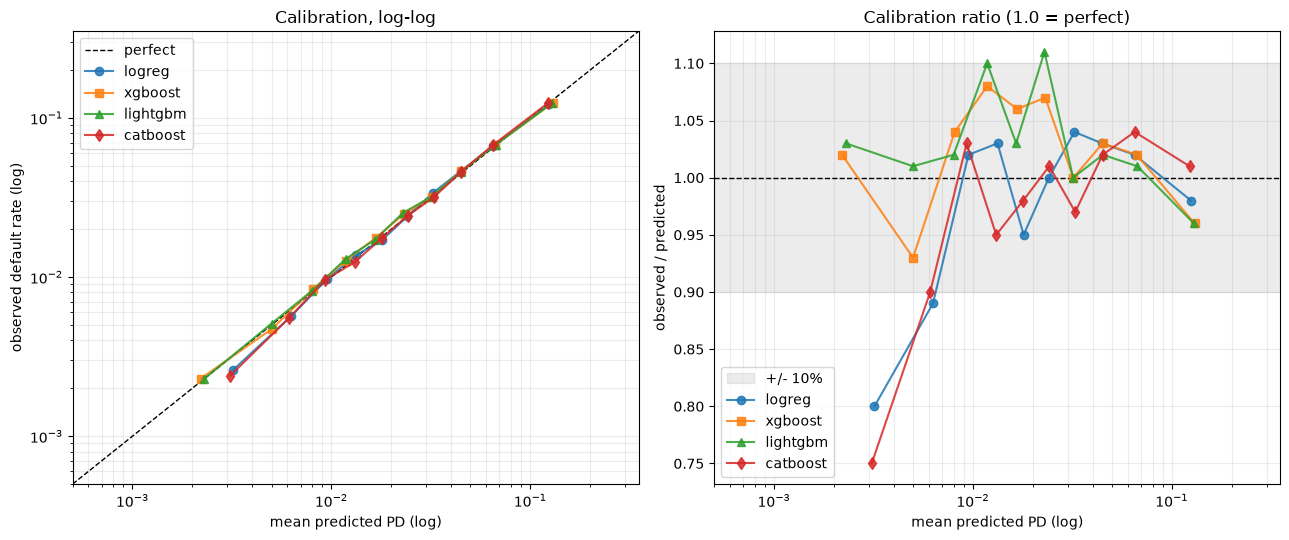

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

mk = {"logreg": "o-", "xgboost": "s-", "lightgbm": "^-", "catboost": "d-"}

lims = (5e-4, 0.35)
a = ax[0]
a.plot(lims, lims, "k--", lw=1, label="perfect")
for k, t in tables.items():
    a.plot(t["pred"], t["obs"], mk[k], label=k, ms=6, alpha=0.85)
a.set_xscale("log"); a.set_yscale("log")
a.set_xlim(*lims); a.set_ylim(*lims)
a.set_xlabel("mean predicted PD (log)")
a.set_ylabel("observed default rate (log)")
a.set_title("Calibration, log-log")
a.legend(); a.grid(alpha=0.25, which="both")

a = ax[1]
a.axhspan(0.9, 1.1, color="grey", alpha=0.15, label="+/- 10%")
a.axhline(1.0, color="k", ls="--", lw=1)
for k, t in tables.items():
    a.plot(t["pred"], t["ratio"], mk[k], label=k, ms=6, alpha=0.85)
a.set_xscale("log")
a.set_xlim(*lims)
a.set_xlabel("mean predicted PD (log)")
a.set_ylabel("observed / predicted")
a.set_title("Calibration ratio (1.0 = perfect)")
a.legend(); a.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

## Finding: plots confirm calibration; the ratio view misleads

All four models sit on the diagonal across three orders of magnitude. Calibration
confirmed by eye, not just by ECE.

**The ratio panel is the wrong lens.** The LP objective is
`c_i = (1-PD)·I - PD·L`. It is linear in PD, so an error of 0.005 costs the same
whether the PD is 0.01 or 0.12. Only the size of the error matters, not the
percentage.

| | ratio | actual error |
|---|---|---|
| CatBoost bin 0 | 0.75, looks bad | 0.0008 |
| XGBoost bin 9 | 0.96, looks fine | 0.0056 |

XGBoost is off by 7x more in the units the LP cares about. ECE already measures
error size, so it stays the metric. Use the ratio panel to see shape, not to pick
a model.

**The tails split.** The overfit models (XGBoost, LightGBM) get the safest loans
right and overshoot the riskiest. CatBoost does the opposite. Its regularization
helps where data is thin and hurts where predictions need to be extreme.

## Isotonic calibration

**What:** fit isotonic regression on the `calib` split, apply it to `test`,
compare ECE / Brier / AUC before and after.

**Why isotonic:** it learns any increasing mapping from predicted to true
probability without assuming a shape. Platt scaling forces a sigmoid; isotonic
does not. Because the mapping only ever increases, it cannot reorder loans, so
AUC should barely move.

**Why `calib` and not `train`:** on train it would learn to correct predictions
the models had memorized, and the mapping would be wrong for new loans. `calib`
is 409,353 loans with 14,094 positives, never seen during training.

**Success is not "ECE improves."** The models are already near the measurement
floor. Success is ECE not getting worse, plus a smaller error in bin 9.

**The check that matters:** isotonic can output exactly 0. A PD of 0 tells the LP
a loan is risk-free, and that loan wins the objective outright. Counted below.

In [29]:
from sklearn.isotonic import IsotonicRegression

t = time.time()
p_ca = {
    "logreg":   logreg.predict_proba(X_ca)[:, 1],
    "xgboost":  xgb.predict_proba(X_ca)[:, 1],
    "lightgbm": lgbm.predict_proba(X_ca)[:, 1],
    "catboost": cat.predict_proba(X_ca)[:, 1],
}
print(f"calib preds : {time.time()-t:5.1f}s")

isos, p_iso = {}, {}
for k in preds:
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    iso.fit(p_ca[k], y_ca)
    isos[k] = iso
    p_iso[k] = iso.predict(preds[k])

print("\n--- zero-PD check ---")
for k, v in p_iso.items():
    print(f"  {k:9} zeros: {(v == 0).sum():6,}   min: {v.min():.6f}   max: {v.max():.4f}")

tables_iso, eces_iso = {}, {}
for k, v in p_iso.items():
    tables_iso[k], eces_iso[k] = calib_table(y_te, v, f"{k} +iso")

print("\n--- before / after ---")
print(f"{'model':10} {'ECE raw':>9} {'ECE iso':>9} {'delta':>9}   "
      f"{'Brier raw':>10} {'Brier iso':>10}   {'AUC raw':>8} {'AUC iso':>8}")
for k in preds:
    br = brier_score_loss(y_te, preds[k])
    bi = brier_score_loss(y_te, p_iso[k])
    ar = roc_auc_score(y_te, preds[k])
    ai = roc_auc_score(y_te, p_iso[k])
    print(f"{k:10} {eces[k]:9.5f} {eces_iso[k]:9.5f} {eces_iso[k]-eces[k]:+9.5f}   "
          f"{br:10.6f} {bi:10.6f}   {ar:8.4f} {ai:8.4f}")

print("\nfloor ~0.0006  |  negative delta = improved")

calib preds :   1.5s

--- zero-PD check ---
  logreg    zeros:  1,235   min: 0.000000   max: 0.4444
  xgboost   zeros:    316   min: 0.000000   max: 0.2857
  lightgbm  zeros:    672   min: 0.000000   max: 0.3871
  catboost  zeros:  3,168   min: 0.000000   max: 0.7500

logreg +iso  ECE 0.00117   Brier 0.031577   AUC 0.7702
shape: (10, 6)
┌─────┬───────┬────────┬────────┬─────────┬───────┐
│ bin ┆ n     ┆ pred   ┆ obs    ┆ gap     ┆ ratio │
│ --- ┆ ---   ┆ ---    ┆ ---    ┆ ---     ┆ ---   │
│ i64 ┆ i64   ┆ f64    ┆ f64    ┆ f64     ┆ f64   │
╞═════╪═══════╪════════╪════════╪═════════╪═══════╡
│ 0   ┆ 37334 ┆ 0.0027 ┆ 0.0025 ┆ -0.0002 ┆ 0.91  │
│ 1   ┆ 33822 ┆ 0.0055 ┆ 0.0046 ┆ -0.0009 ┆ 0.83  │
│ 2   ┆ 50549 ┆ 0.008  ┆ 0.0093 ┆ 0.0013  ┆ 1.16  │
│ 3   ┆ 40946 ┆ 0.013  ┆ 0.0136 ┆ 0.0006  ┆ 1.05  │
│ 4   ┆ 34619 ┆ 0.0175 ┆ 0.0161 ┆ -0.0014 ┆ 0.92  │
│ 5   ┆ 40359 ┆ 0.0223 ┆ 0.0231 ┆ 0.0008  ┆ 1.04  │
│ 6   ┆ 44845 ┆ 0.0316 ┆ 0.0323 ┆ 0.0007  ┆ 1.02  │
│ 7   ┆ 35287 ┆ 0.0455 ┆ 0.0426 ┆ -0.

## Finding: isotonic changes nothing and costs a little

| model | ECE raw | ECE iso | delta | AUC raw | AUC iso |
|---|---|---|---|---|---|
| logreg | 0.00103 | 0.00117 | +0.00014 | 0.7705 | 0.7702 |
| xgboost | 0.00123 | 0.00100 | -0.00023 | 0.7781 | 0.7780 |
| lightgbm | 0.00114 | 0.00096 | -0.00018 | 0.7768 | 0.7766 |
| catboost | 0.00086 | 0.00094 | +0.00008 | 0.7750 | 0.7747 |

Every delta is smaller than the ~0.0006 measurement floor. Two models improved,
two got worse. That pattern is noise, not signal. Brier is unchanged to the fifth
decimal.

**It costs AUC.** All four dropped. Isotonic maps distinct predictions to the same
value, which destroys ranking information. The bin counts show it: raw bins were
all ~40,993 by construction, but after isotonic LogReg's bin 1 holds 33,822 and
bin 2 holds 50,549. Those are ties.

**It introduces PD = 0.** Every model now has loans it calls risk-free:

| model | zeros | max |
|---|---|---|
| catboost | 3,168 | 0.75 |
| logreg | 1,235 | 0.4444 |
| lightgbm | 672 | 0.3871 |
| xgboost | 316 | 0.2857 |

A PD of 0 tells the LP the loan cannot default, so its expected return is the full
interest and it gets funded first. Nothing in the data supports that claim. It
happens because isotonic's bottom block covered a stretch of `calib` where no
loans defaulted, and it has no prior pulling it off zero.

**The tail rests on tiny samples.** Those max values are simple fractions: 0.75,
4/9, 2/7. Isotonic's top block is a handful of loans, and its estimate of the
riskiest PDs is fit on single-digit counts.

**Decision: ship raw predictions.** The models were already calibrated.
Isotonic's only measurable effects here are lost AUC and impossible PDs. This
does not mean isotonic is wrong in general. Under an IID split there is nothing
for it to correct. Under a temporal split across vintages there would be.

## Model selection: CatBoost

| | CatBoost | XGBoost |
|---|---|---|
| Test AUC | 0.7750 | 0.7781 |
| Brier | 0.031480 | 0.031481 |
| ECE | 0.00086 | 0.00123 |
| Train-test gap | 0.0064 | 0.0384 |

AUC and Brier are ties. The 0.0031 AUC difference is inside noise at 13,982
positives, and Brier separates them at the sixth decimal.

The train-test gap does not tie. CatBoost's is 6x smaller, meaning it is not
leaning on memorized training rows. That matters because our calibration result
already carries an IID caveat: it holds because train and test are the same
distribution. Shipping the model with the larger gap alongside that caveat is a
weak position.

**Decision:** CatBoost, raw predictions, no isotonic. Untuned. This notebook is
scaffolding to unblock the LP; track 1 delivers the tuned model in week 6.